<a href="https://colab.research.google.com/github/taras-ivanyk/nn-zero-to-hero/blob/main/MLP_Makemore_Part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cross-Entropy:

# logits = torch.tensor([0, 4, -3, 100]) - 100
# counts = logits.exp()
# probs = counts / counts.sum()
# probs

In [ ]:
# loss = -probs[torch.arange(32), Y].log().mean()
# loss

In [ ]:
import requests
url = "https://raw.githubusercontent.com/karpathy/makemore/master/names.txt"
r = requests.get(url)
r.raise_for_status()
open("names.txt", "wb").write(r.content)

# read into a list of names
with open("names.txt", "r", encoding="utf-8") as f:
    names = [line.strip() for line in f if line.strip()]
print(len(names), "names; first 20:")
print(names[:20])

words = names

32033 names; first 20:
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn', 'abigail', 'emily', 'elizabeth', 'mila', 'ella', 'avery', 'sofia', 'camila', 'aria', 'scarlett']


In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [ ]:
# build the dataset

block_size = 3
X, Y = [], []

for w in words:

  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [ ]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [ ]:
C = torch.randn(27, 2)

In [ ]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [ ]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [ ]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

torch.Size([228146, 6])

In [ ]:
emb.shape

torch.Size([228146, 3, 2])

In [ ]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h.shape

torch.Size([228146, 100])

In [ ]:
W2 = torch.randn(100, 27)
b2 = torch.randn(27)

logits = h @ W2 + b2
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)

In [ ]:
# ------------ now made respectable :) -----------------

In [ ]:
def build_the_dataset(words):
  block_size = 3
  X, Y = [], []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_the_dataset(words[:n1])
Xdev, Ydev = build_the_dataset(words[n1:n2])
Xtest, Ytest = build_the_dataset(words[n2:])

torch.Size([182437, 3]) torch.Size([182437])
torch.Size([22781, 3]) torch.Size([22781])
torch.Size([22928, 3]) torch.Size([22928])


In [ ]:
n1, n2, n2-n1

(25626, 28829, 3203)

In [ ]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200,
generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

In [ ]:
sum(p.nelement() for p in parameters)

18167

In [ ]:
for p in parameters:
  p.requires_grad = True

In [ ]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [ ]:
lri = []
lossi = []
stepi = []

# Track time:
import time
start_time = time.time()
# ================

for i in range(200000):

  ix = torch.randint(0, Xtr.shape[0], (32, ))

  emb = C[Xtr[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  # lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

# print(loss.item())

# Calculate time
end_time = time.time()
elapsed_time = end_time - start_time

print(elapsed_time)

88.84114861488342


In [ ]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0690, grad_fn=<NllLossBackward0>)

In [ ]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh((emb.view(-1, 30)) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1685, grad_fn=<NllLossBackward0>)

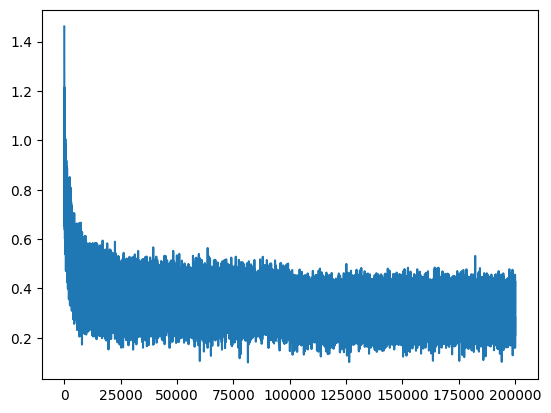

In [ ]:
plt.plot(stepi, lossi)

In [ ]:
C[:,0], C[:, 1]

(tensor([ 1.7609, -0.2139,  0.4712, -0.1603,  0.1578, -0.3477,  0.1535,  0.2210,
         -0.7773, -0.4167, -0.7488, -0.2354, -0.2179, -0.8915,  0.1352, -0.2231,
         -0.7464,  0.7133,  0.2192,  0.0737,  0.0665, -0.2437,  0.0988,  0.0813,
          0.3109, -0.4954,  0.1125], grad_fn=<SelectBackward0>),
 tensor([-0.1455,  0.4870,  0.0464,  0.0549, -0.1271,  0.3168,  0.1433,  0.2093,
          0.2148,  0.1270, -0.8825, -0.0919,  0.1107,  0.1930, -0.3332,  0.3382,
          1.5680,  0.7266, -0.0556, -0.0089,  0.0584,  0.3286, -0.1635,  0.1714,
         -0.0104,  0.1376, -0.1394], grad_fn=<SelectBackward0>))

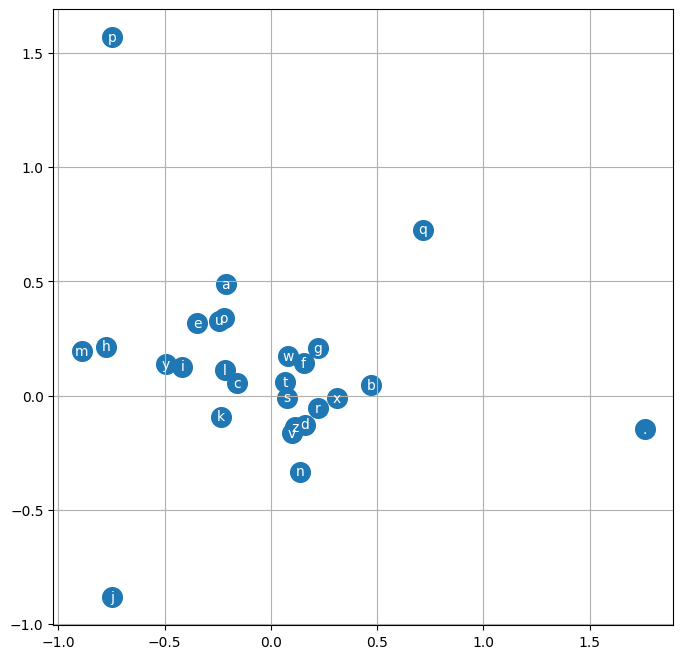

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:,0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
  plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha="center", va="center",color = "white")
plt.grid("minor")

In [ ]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

  out = []
  context = [0] * block_size

  while True:
    emb = C[torch.tensor([context])]
    h = torch.tanh(emb.view(1, -1) @ W1 + b1)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break

  print(''.join(itos[i] for i in out))

chrelle.
aulie.
khirmre.
reviy.
hochssne.
rehell.
emeryne.
vaeli.
nekonesteeriiv.
keleig.
hell.
evin.
quinnes.
lelei.
vie.
quwwoelle.
jarynike.
jennies.
toed.
emigh.


In [ ]:
emb = C[torch.tensor([context])]
h = torch.tanh(emb.view(1, -1) @ W1 + b1)
logits = h @ W2 + b2
probs = F.softmax(logits, dim=1)
ix = torch.multinomial(probs, num_samples=1, generator=g).item()

# emb, emb.view(1, -1) @ W1 + b1, h
logits, probs, ix, probs.sum()

(tensor([[  9.0363,   2.9612,   2.9637,  -6.6830,  -3.4746,   5.2772,  -3.6118,
          -11.7116,  -3.2795,   0.4274,  -0.2047, -10.2563,   4.9363,  -6.9833,
           -5.7762,   6.3063,   0.0480, -12.6412,  -4.3306,   1.2569,   3.3295,
            3.5410,  -7.2788,  11.2309,  -8.7410,  -0.3380, -13.8202]],
        grad_fn=<AddBackward0>),
 tensor([[9.9063e-02, 2.2777e-04, 2.2836e-04, 1.4761e-08, 3.6517e-07, 2.3085e-03,
          3.1836e-07, 9.6651e-11, 4.4385e-07, 1.8076e-05, 9.6074e-06, 4.1424e-10,
          1.6417e-03, 1.0931e-08, 3.6553e-08, 6.4607e-03, 1.2369e-05, 3.8148e-11,
          1.5514e-07, 4.1432e-05, 3.2923e-04, 4.0676e-04, 8.1344e-09, 8.8924e-01,
          1.8851e-09, 8.4080e-06, 1.1735e-11]], grad_fn=<SoftmaxBackward0>),
 23,
 tensor(1.0000, grad_fn=<SumBackward0>))

In [ ]:
context = [0] * block_size
torch.tensor(context)

tensor([0, 0, 0])

# ================ Exercise ==================
# Try to beat 2.17 loss on dev using:
## - Increase dimensionality
## - Increase input characters (context)
## - Change number of iterations
## - Change batch size (find trade-off between speed and accuracy)
## - Find some good learning rates
## - Increase number of neurons in the layer

# ====================== REMARK ========================

# I was training all of it with 20000 epochs and lr = 0.1 if epoch < 10000 else 0.01

# ======================================================

# Batch size:

| Batch Size | Trloss | Devloss | Time (sec) |
| :--- | :--- | :--- | :--- |
| 32 | 2.3329 | 2.3651 | 8.36 |
| 64 | 2.2893 | 2.3134 | 9.6 |
| 128 | 2.2833 | 2.3178 | 13.5 |
| 256 | 2.2758 | 2.3030 | 20.8 |
| 1024 |2.2716 | 2.2946 | 65.5 |


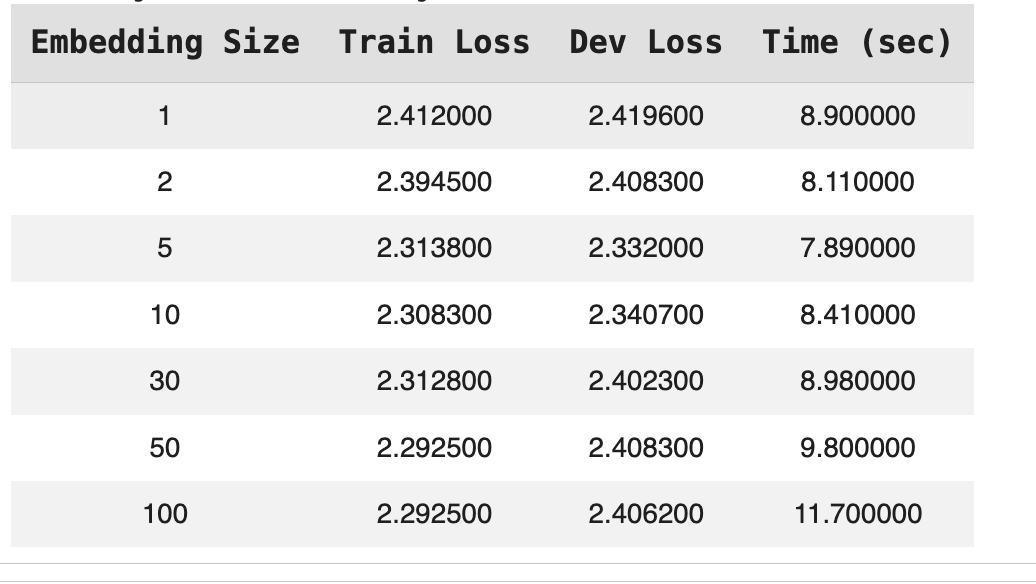

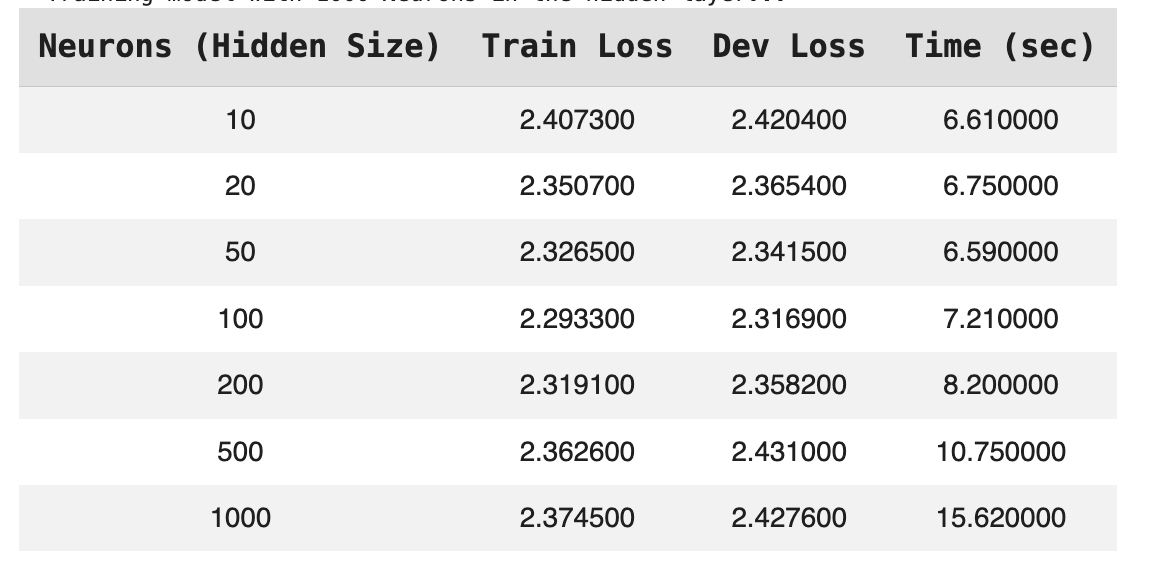

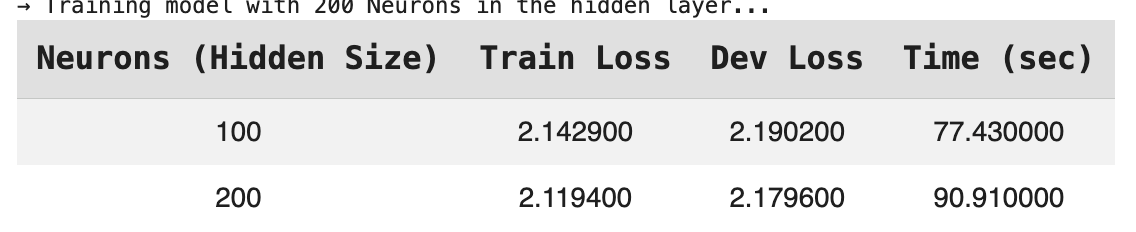
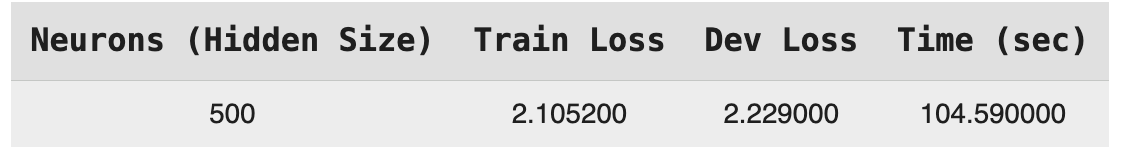

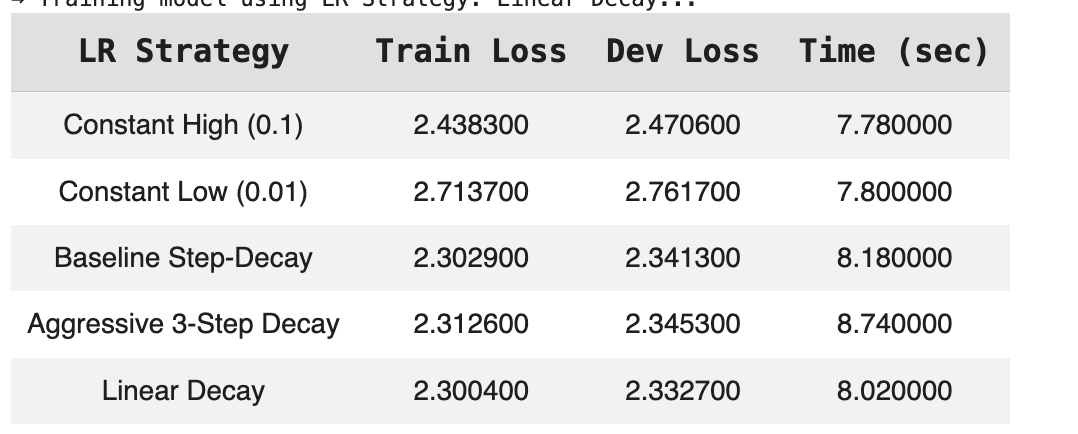